<a href="https://colab.research.google.com/github/Huyen-005/THDeepLearning/blob/main/Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 5 Dòng dữ liệu đầu tiên từ file gốc ---
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  7.1  7.3  7.4   M   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.1  7.5  7.2   M   

   DT   KV   DH1   DH2   DH3  KT  
0 NaN  2NT  3.25  3.25  4.50  A1  
1 NaN    1  6.00  4.00  3.50   C  
2 NaN    1  5.00  6.75  4.00   C  
3 NaN    1  4.25  4.25  5.25  D1  
4 NaN  2NT  4.25  4.50  5.00   A  

[5 rows x 56 columns]

=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===
Kích thước tập Huấn luyện (X_train_scaled): (80, 5)
Kích thước tập Kiểm định  (X_val_scaled):   (20, 5)

--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MÔ HÌNH BẰNG GRADIENT DESCENT ---
Vòng lặp  10/100 | Sai số tập H

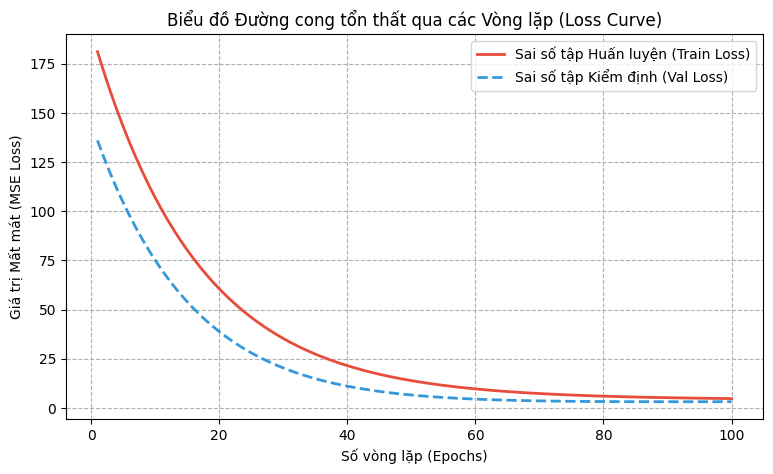


=== KẾT QUẢ TRỌNG SỐ TỐI ƯU CUỐI CÙNG CỦA MÔ HÌNH ===
Hệ số chặn tự do (Bias - b): 8.2252

Danh sách các Trọng số tương ứng với từng biến đầu vào (Weights - W):
 -> Trọng số của đặc trưng [T6   ]: +0.5745
 -> Trọng số của đặc trưng [L6   ]: -0.0063
 -> Trọng số của đặc trưng [H6   ]: +0.1396
 -> Trọng số của đặc trưng [GT_F ]: +4.5573
 -> Trọng số của đặc trưng [GT_M ]: +3.8707


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# BƯỚC 1: CHUẨN BỊ DỮ LIỆU -> LÀM SẠCH DỮ LIỆU (Theo sơ đồ trên bảng)
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/dulieuxettuyendaihoc.csv"
df = pd.read_csv(url)

print("--- 5 Dòng dữ liệu đầu tiên từ file gốc ---")
print(df.head())

# Định nghĩa các đặc trưng đầu vào (Features)
features_numeric = ['T6', 'L6', 'H6']   # Biến liên tục: Điểm Toán, Lý, Hóa học kỳ 2 lớp 12
features_categorical = ['GT']             # Biến danh mục: Giới tính (F/M)
target_column = 'TONG_DIEM_DH'            # Biến liên tục mục tiêu cần dự đoán

# Tính tổng điểm thi đại học thực tế của 3 môn (DH1 + DH2 + DH3) làm giá y
df[target_column] = df['DH1'] + df['DH2'] + df['DH3']

# Làm sạch dữ liệu: Loại bỏ tất cả dòng có chứa giá trị khuyết thiếu (NaN) ở các cột quan trọng
df = df.dropna(subset=features_numeric + features_categorical + [target_column])

# Tách biệt ma trận đặc trưng X và vector mục tiêu y
X = df[features_numeric + features_categorical]
y = df[target_column].values.astype(np.float32) # Chuyển target về float32 để đồng bộ tính toán với TensorFlow


# BƯỚC 2: CHIA DỮ LIỆU (TRAIN - VAL) & TIỀN XỬ LÝ (TUÂN THỦ CHỐNG DATA LEAKAGE)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng bộ tiền xử lý đồng bộ ColumnTransformer:
# - Cột số: Chuẩn hóa StandardScaler (Z-score) đưa về phân phối có mean=0, std=1
# - Cột chữ: Mã hóa OneHotEncoder giúp chuyển chuỗi (M/F) thành số nhị phân (0/1)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categorical)
])

# Theo đúng sơ đồ bài giảng: Scaler thực hiện fit_transform trên Train và chỉ transform trên Val
X_train_scaled = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_scaled = preprocessor.transform(X_val).astype(np.float32)

print("\n=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===")
print(f"Kích thước tập Huấn luyện (X_train_scaled): {X_train_scaled.shape}")
print(f"Kích thước tập Kiểm định  (X_val_scaled):   {X_val_scaled.shape}\n")


# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION + GRADIENT DESCENT (TENSORFLOW)
# Lấy số lượng đặc trưng đầu vào sau khi ma trận đã được mở rộng mã hóa (5 cột)
input_dim = X_train_scaled.shape[1]

# Lấy danh sách tên các đặc trưng sau biến đổi để hiển thị trọng số rõ ràng
feature_names = features_numeric + list(preprocessor.named_transformers_['cat'].get_feature_names_out(features_categorical))

# Khởi tạo các biến trọng số W ngẫu nhiên và bias b bằng 0
W = tf.Variable(tf.random.normal([input_dim, 1]), name='weights')
b = tf.Variable(tf.zeros([1]), name='bias')

# Cấu hình các siêu tham số tối ưu hóa
learning_rate = 0.01
epochs = 100

# Khởi tạo các danh sách lưu trữ lịch sử để vẽ đồ thị tổn thất (Loss Curve)
train_loss_history = []
val_loss_history = []

print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MÔ HÌNH BẰNG GRADIENT DESCENT ---")

for epoch in range(1, epochs + 1):
    # Sử dụng tf.GradientTape để theo dõi và tự động tính toán đạo hàm riêng (Gradients)
    with tf.GradientTape() as tape:
        # 1. Dự đoán giá trị điểm số dựa trên phương trình hồi quy tuyến tính: y_pred = X * W + b
        y_train_pred = tf.matmul(X_train_scaled, W) + b
        # 2. Tính toán hàm mất mát bằng Sai số bình phương trung bình (MSE - Mean Squared Error) [cite: 1897]
        train_loss = tf.reduce_mean(tf.square(y_train_pred - y_train.reshape(-1, 1)))

    # 3. Tính toán Gradients (đạo hàm riêng) của hàm Loss đối với các biến tham số W và b
    dW, db = tape.gradient(train_loss, [W, b])

    # 4. Cập nhật các trọng số và bias ngược chiều Gradient theo thuật toán Gradient Descent [cite: 1902]
    W.assign_sub(learning_rate * dW)
    b.assign_sub(learning_rate * db)

    # 5. Tính toán sai số (Loss) trên tập Kiểm định độc lập để theo dõi quá trình hội tụ
    y_val_pred = tf.matmul(X_val_scaled, W) + b
    val_loss = tf.reduce_mean(tf.square(y_val_pred - y_val.reshape(-1, 1)))

    # Lưu lại giá trị lịch sử của từng Epoch phục vụ vẽ biểu đồ đồ thị
    train_loss_history.append(train_loss.numpy())
    val_loss_history.append(val_loss.numpy())

    # In kết quả theo dõi tiến trình rõ ràng bằng tiếng Việt sau mỗi 10 vòng lặp
    if epoch % 10 == 0:
        print(f"Vòng lặp {epoch:3d}/{epochs} | Sai số tập Học (Train Loss): {train_loss.numpy():.4f} | Sai số tập Kiểm định (Val Loss): {val_loss.numpy():.4f}")


# BƯỚC 4: TRỰC QUAN HÓA: VẼ ĐỒ THỊ LOSS CURVE (Giống hình vẽ trên bảng)
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Sai số tập Huấn luyện (Train Loss)', color='#e74c3c', linewidth=2)
plt.plot(range(1, epochs + 1), val_loss_history, label='Sai số tập Kiểm định (Val Loss)', color='#3498db', linewidth=2, linestyle='--')
plt.title('Biểu đồ Đường cong tổn thất qua các Vòng lặp (Loss Curve)')
plt.xlabel('Số vòng lặp (Epochs)')
plt.ylabel('Giá trị Mất mát (MSE Loss)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()


# BƯỚC 5: XUẤT KẾT QUẢ CÁC TRỌNG SỐ TỐI ƯU CUỐI CÙNG TÌM ĐƯỢC
print("\n=== KẾT QUẢ TRỌNG SỐ TỐI ƯU CUỐI CÙNG CỦA MÔ HÌNH ===")
print(f"Hệ số chặn tự do (Bias - b): {b.numpy()[0]:.4f}\n")
print("Danh sách các Trọng số tương ứng với từng biến đầu vào (Weights - W):")
for name, weight in zip(feature_names, W.numpy().flatten()):
    print(f" -> Trọng số của đặc trưng [{name:5s}]: {weight:+.4f}")

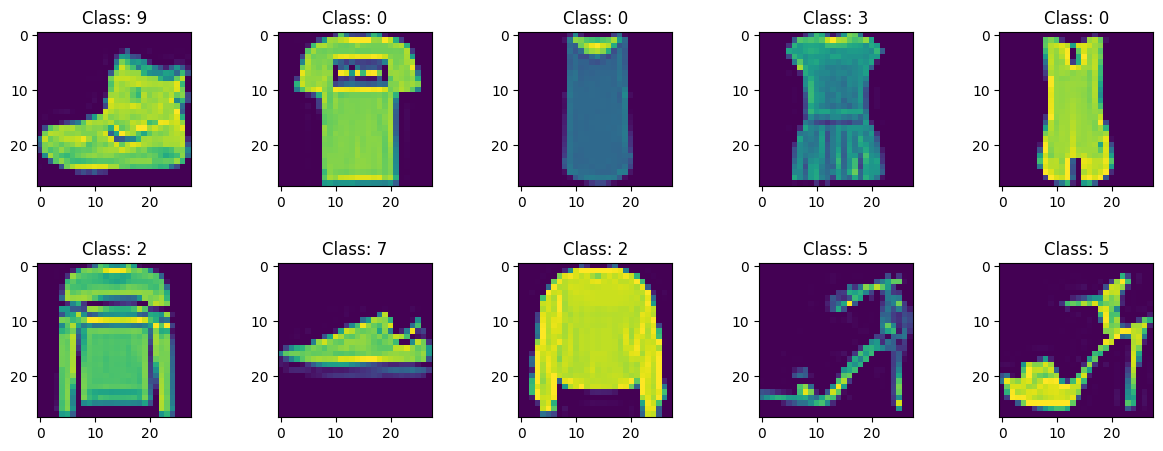

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8223 - loss: 0.5072 - val_accuracy: 0.8598 - val_loss: 0.3829
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8662 - loss: 0.3694 - val_accuracy: 0.8737 - val_loss: 0.3634
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8786 - loss: 0.3319 - val_accuracy: 0.8742 - val_loss: 0.3480
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8877 - loss: 0.3067 - val_accuracy: 0.8842 - val_loss: 0.3282
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8936 - loss: 0.2882 - val_accuracy: 0.8687 - val_loss: 0.3617
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8986 - loss: 0.2736 - val_accuracy: 0.8750 - val_loss: 0.3443
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9026 - loss: 0.2609 - val_accuracy: 0.8887 - val_loss: 0.3265
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9050 - loss: 0.2511 - 

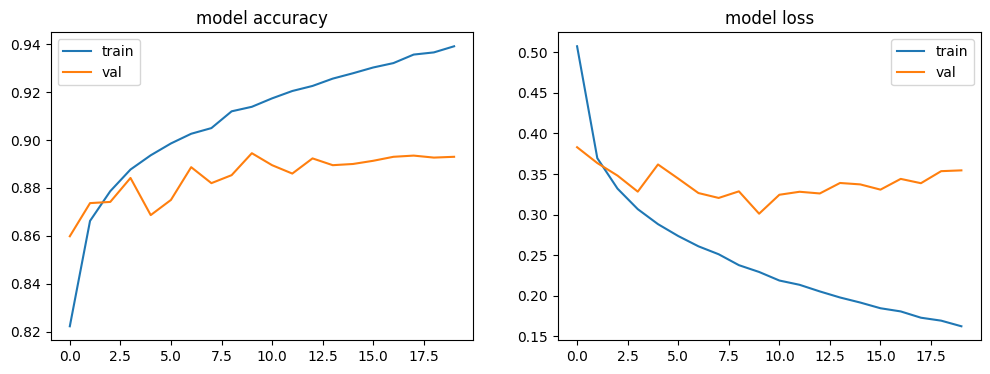

Lưu ý: Không tìm thấy file /content/sample_data/dress.jpg. Vui lòng tải ảnh lên để dự báo.
Thông báo: File CSV không tồn tại, bỏ qua bước nạp từ file.


In [ ]:
#3. CÀI ĐẶT ARTIFICIAL NEURAL NETWORK CƠ BẢN
# 1. NẠP THƯ VIỆN (Mục 3.1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import MinMaxScaler

# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU (Mục 3.2 & 3.3)
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

# 3.4. Trực quan hóa dữ liệu
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i])
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# Reshape và Chuẩn hóa (Mục 3.3)
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

# 3.5. XÂY DỰNG MÔ HÌNH ANN (Đã sửa lỗi cảnh báo Input)
fashion_model = Sequential([
    Input(shape=(784,)), # Thay cho input_dim để tránh UserWarning
    Dense(units=256, kernel_initializer='uniform', activation='relu'),
    Dense(units=10, kernel_initializer='uniform', activation='softmax')
])

fashion_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
fashion_model.summary()

# 3.6. HUẤN LUYỆN MÔ HÌNH
model_fit = fashion_model.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=20,
                              verbose=1)

# 3.7. ĐÁNH GIÁ MÔ HÌNH (ACCURACY & LOSS)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.legend()
plt.show()

# 3.8. DỰ BÁO ẢNH MỚI (Xử lý lỗi FileNotFoundError)
import os
img_path = '/content/sample_data/dress.jpg'

if os.path.exists(img_path):
    img_size = (28, 28)
    img = tf.keras.preprocessing.image.load_img(img_path, color_mode='grayscale', target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.squeeze(img_array)
    img_reshaped = np.reshape(img_array, (784))
    img_final = tf.expand_dims(img_reshaped, 0)

    img_predict = fashion_model.predict(img_final)
    print("Kết quả dự báo cho ảnh mới:", np.argmax(img_predict))
else:
    print(f"Lưu ý: Không tìm thấy file {img_path}. Vui lòng tải ảnh lên để dự báo.")

# 3.9. ĐỌC TẬP DỮ LIỆU TỪ FILE CSV (NẾU CÓ)
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
if os.path.exists(mnist_train_path):
    mnist_train = pd.read_csv(mnist_train_path)
    X_train_csv = mnist_train.iloc[:, 1:]
    y_train_csv = mnist_train.iloc[:, 0]
    print('Kích thước tập huấn luyện từ CSV:', X_train_csv.shape)
else:
    print("Thông báo: File CSV không tồn tại, bỏ qua bước nạp từ file.")

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN TỪ FILE GỐC ---
    age sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0   M  tap     145.0  233.0  yes      2.0    150.0    0.0      2.3   
1  67.0   M  asp     160.0  286.0   no      2.0    108.0    1.0      1.5   
2  67.0   M  asp     120.0  229.0   no      2.0    129.0    1.0      2.6   
3  37.0   M  nap     130.0  250.0   no      0.0    187.0    0.0      3.5   
4  41.0   F  aap     130.0  204.0   no      2.0    172.0    0.0      1.4   

   slope   ca  thal  state  
0    3.0  0.0   6.0    0.0  
1    2.0  3.0   3.0    2.0  
2    2.0  2.0   7.0    1.0  
3    3.0  0.0   3.0    0.0  
4    1.0  0.0   3.0    0.0  

=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===
Kích thước tập huấn luyện (X_train_processed): (227, 18)
Kích thước tập kiểm thử   (X_test_processed):  (57, 18)



Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.1912 - loss: 0.6857 - val_accuracy: 0.3043 - val_loss: 0.6839
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1863 - loss: 0.6554 - val_accuracy: 0.3043 - val_loss: 0.6575
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1863 - loss: 0.5837 - val_accuracy: 0.3043 - val_loss: 0.5915
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1863 - loss: 0.4107 - val_accuracy: 0.3043 - val_loss: 0.4662
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1863 - loss: 0.1294 - val_accuracy: 0.3043 - val_loss: 0.2978
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1863 - loss: -0.2473 - val_accuracy: 0.3043 - val_loss: 0.1201
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1863 - loss: -0.7238 - val_accuracy: 0.3043 - val_loss: -0.1052
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1863 - loss: -1.3063 - val_accuracy: 0.3043

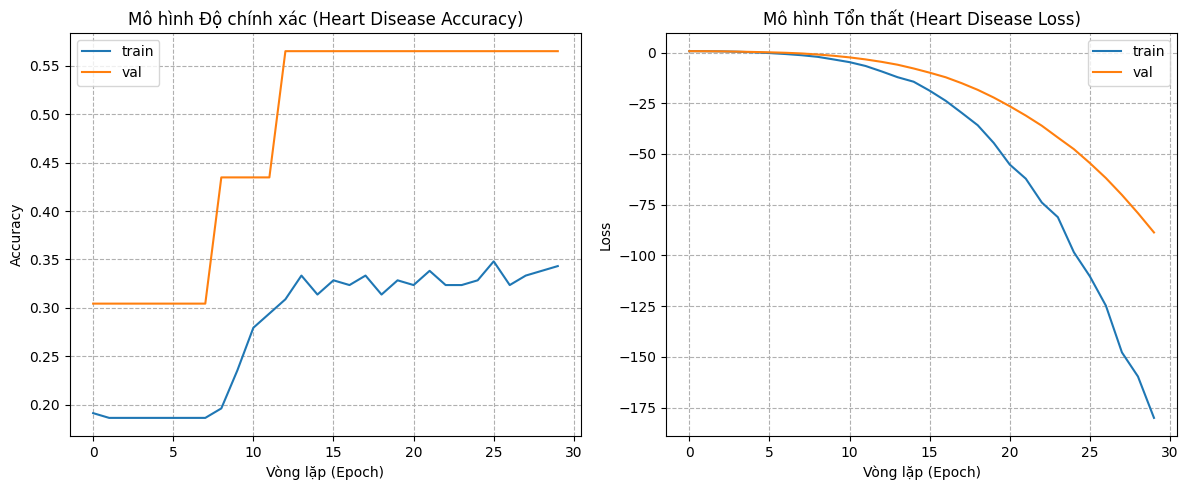


=> Độ chính xác cuối cùng trên tập Test độc lập: 36.84%


In [ ]:
# CÀI ĐẶT MẠNG ANN DỰ BÁO BỆNH TIM (HEART DISEASE)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU TỪ URL GITHUB GỐC
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/heart_disease_dataset.csv"
df_heart = pd.read_csv(url)

print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN TỪ FILE GỐC ---")
print(df_heart.head())

# ĐÃ SỬA LỖI: Đổi từ 'target' thành 'state' theo đúng tên cột trong file CSV của bạn
target_column = 'state'

# Làm sạch dữ liệu: Loại bỏ các dòng khuyết thiếu (NaN)
df_heart = df_heart.dropna()

# Tách biệt ma trận đặc trưng X và vector nhãn mục tiêu y
X = df_heart.drop(columns=[target_column])
y = df_heart[target_column].values

# Tự động phân loại danh sách các cột số và cột chữ (định tính)
features_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_categorical = X.select_dtypes(include=['object']).columns.tolist()


# 2. CHIA TÁCH DỮ LIỆU (TRAIN - TEST) & TIỀN XỬ LÝ (CHỐNG DATA LEAKAGE)
# Quy tắc vàng: Phân rã dữ liệu TRƯỚC KHI thực hiện bất kỳ phép ép dải số nào
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng bộ tiền xử lý đồng bộ ColumnTransformer:
# - Cột số: Ép dải về [0, 1] bằng MinMaxScaler (Giống bài Fashion MNIST mẫu)
# - Cột chữ: Mã hóa OneHotEncoder đưa biến định tính về ma trận nhị phân
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), features_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categorical)
])

# Học thông số thống kê từ tập huấn luyện (Train) và áp dụng biến đổi (Transform) lên cả hai tập
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===")
print(f"Kích thước tập huấn luyện (X_train_processed): {X_train_processed.shape}")
print(f"Kích thước tập kiểm thử   (X_test_processed):  {X_test_processed.shape}\n")


# 3. XÂY DỰNG KIẾN TRÚC MẠNG ANN PHÂN LOẠI NHỊ PHÂN
input_dim = X_train_processed.shape[1]

heart_model = Sequential([
    Input(shape=(input_dim,)), # Lớp đầu vào chuẩn Keras mới tránh UserWarning
    Dense(units=64, kernel_initializer='uniform', activation='relu'), # Tầng ẩn 1
    Dropout(0.2),                                                     # Kỹ thuật Dropout chống overfitting
    Dense(units=32, kernel_initializer='uniform', activation='relu'), # Tầng ẩn 2
    Dense(units=1, kernel_initializer='uniform', activation='sigmoid') # 1 nút đầu ra + Sigmoid cho xác suất bệnh (0 hoặc 1)
])

# Biên dịch mô hình với hàm loss dành riêng cho phân loại nhị phân
heart_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
heart_model.summary()


# 4. HUẤN LUYỆN MÔ HÌNH
model_fit = heart_model.fit(X_train_processed, y_train,
                            validation_split=0.1,
                            epochs=30,
                            batch_size=16,
                            verbose=1)


# 5. ĐÁNH GIÁ MÔ HÌNH (TRỰC QUAN HÓA ACCURACY & LOSS GIỐNG BÀI MẪU TRÊN LAB)
plt.figure(figsize=(12, 5))

# Đồ thị biểu diễn Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Mô hình Độ chính xác (Heart Disease Accuracy)')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--')

# Đồ thị biểu diễn Hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Mô hình Tổn thất (Heart Disease Loss)')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


# 6. ĐÁNH GIÁ CHẤT LƯỢNG THỰC TẾ TRÊN TẬP TEST ĐỘC LẬP
loss, accuracy = heart_model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\n=> Độ chính xác cuối cùng trên tập Test độc lập: {accuracy * 100:.2f}%")

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN TỪ FILE GỐC ---
    /Profile/Expedition439245  bubble_50  \
0  /Profile/F4416DUstephaniet  bubble_50   
1         /Profile/447ximenaa  bubble_50   
2              /Profile/P2H72  bubble_40   
3            /Profile/anneroe  bubble_50   
4         /Profile/Flyuphidog  bubble_50   

  Love the music and atmosphere outside by the bar.  If you get a cabana Eddy and PJ are fantastic, they set you up, come and ask often if you need food/drink so you can just unwind and enjoy the view/weather.  Shaina was fantastic at the front desk, even provided us a bottle of wine for our anniversary   Right on oceans avenue!  \
0  All staff is helpful and pleasant! Today I was...                                                                                                                                                                                                                                                                                         
1                      

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 891)            │        57,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,299 (1.23 MB)

 Trainable params: 322,299 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6139 - loss: 3.7594 - val_accuracy: 0.6245 - val_loss: 1.8012
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.6431 - val_accuracy: 0.6245 - val_loss: 1.5199
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.4812 - val_accuracy: 0.6245 - val_loss: 1.4979
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.4317 - val_accuracy: 0.6245 - val_loss: 1.4820
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.3928 - val_accuracy: 0.6245 - val_loss: 1.4854
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.3621 - val_accuracy: 0.6245 - val_loss: 1.4738
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 1.3282 - val_accuracy: 0.6245 - val_loss: 1.5013
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6267 - loss: 1.2860 - val_accuracy: 0

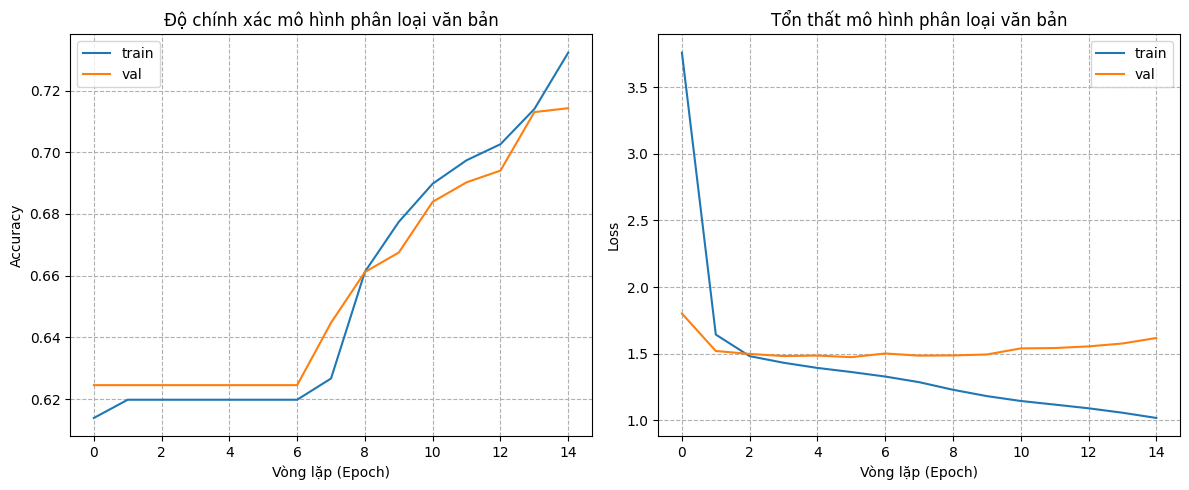


=> Độ chính xác cuối cùng trên tập Test văn bản: 70.80%


In [ ]:
# CÀI ĐẶT MẠNG ANN PHÂN LOẠI VĂN BẢN TRÊN DATASET TRIPADVISOR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU TỪ URL GITHUB GỐC
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/tripadvisor.csv"

# Nạp dữ liệu và đặt tên cột tạm thời vì file gốc có thể không có header chuẩn
df_trip = pd.read_csv(url)

print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN TỪ FILE GỐC ---")
print(df_trip.head())

# Theo cấu trúc dữ liệu in ra của bạn:
# Cột 0: Link Profile (Bỏ qua)
# Cột 1: Nhãn đánh giá (Ví dụ: 'bubble_50', 'bubble_40') -> Đây là Nhãn (y)
# Cột 2: Nội dung đoạn văn text nhận xét -> Đây là Đặc trưng đầu vào (X)

# Định danh lại các cột cốt lõi để xử lý chính xác
df_trip.columns = ['profile', 'rating', 'review_text'] + list(df_trip.columns[3:])

# Loại bỏ các dòng bị khuyết văn bản nhận xét (NaN)
df_trip = df_trip.dropna(subset=['review_text', 'rating'])

# Trích xuất ma trận đặc trưng văn bản X và nhãn y
X_text = df_trip['review_text'].values.astype(str)
y_raw = df_trip['rating'].values.astype(str)

# Mã hóa nhãn chữ ('bubble_50', 'bubble_40'...) về dạng số nguyên từ 0 -> (n-1)
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)
num_classes = len(np.unique(y))


# 2. CHIA TÁCH DỮ LIỆU VÀ BIẾN ĐỔI VĂN BẢN (CHỐNG DATA LEAKAGE)
# Quy tắc vàng: Phân rã dữ liệu chữ trước khi Vector hóa để tránh rò rỉ thông tin
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Chuyển đổi từ ngữ văn bản sang ma trận số số học bằng TF-IDF (Giới hạn tối đa 2000 từ phổ biến nhất)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# Học từ vựng trên tập Train và biến đổi (transform) lên cả hai tập độc lập
X_train_processed = tfidf.fit_transform(X_train_text).toarray().astype(np.float32)
X_test_processed = tfidf.transform(X_test_text).toarray().astype(np.float32)

print("\n=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN SỐ ===")
print(f"Kích thước tập huấn luyện (X_train_processed): {X_train_processed.shape}")
print(f"Kích thước tập kiểm thử   (X_test_processed):  {X_test_processed.shape}\n")


# 3. XÂY DỰNG KIẾN TRÚC MẠNG ANN PHÂN LOẠI ĐA LỚP (TEXT CLASSIFICATION)
input_dim = X_train_processed.shape[1]

trip_model = Sequential([
    Input(shape=(input_dim,)), # Lớp đầu vào nhận vector từ vựng 2000 chiều
    Dense(units=128, kernel_initializer='uniform', activation='relu'),
    Dropout(0.3),                                                      # Dropout tránh overfitting với dữ liệu văn bản
    Dense(units=64, kernel_initializer='uniform', activation='relu'),
    Dense(units=num_classes, kernel_initializer='uniform', activation='softmax') # Đầu ra đa lớp Softmax
])

# Biên dịch mô hình theo chuẩn bài toán phân loại đa lớp
trip_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
trip_model.summary()


# 4. HUẤN LUYỆN MÔ HÌNH
model_fit = trip_model.fit(X_train_processed, y_train,
                            validation_split=0.1,
                            epochs=15,
                            batch_size=64,
                            verbose=1)


# 5. ĐÁNH GIÁ MÔ HÌNH (TRỰC QUAN HÓA ACCURACY & LOSS GIỐNG BÀI MẪU)
plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Độ chính xác mô hình phân loại văn bản')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Tổn thất mô hình phân loại văn bản')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


# 6. ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
loss, accuracy = trip_model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\n=> Độ chính xác cuối cùng trên tập Test văn bản: {accuracy * 100:.2f}%")

/tmp/ipykernel_1898/1174046480.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(y_train[i])


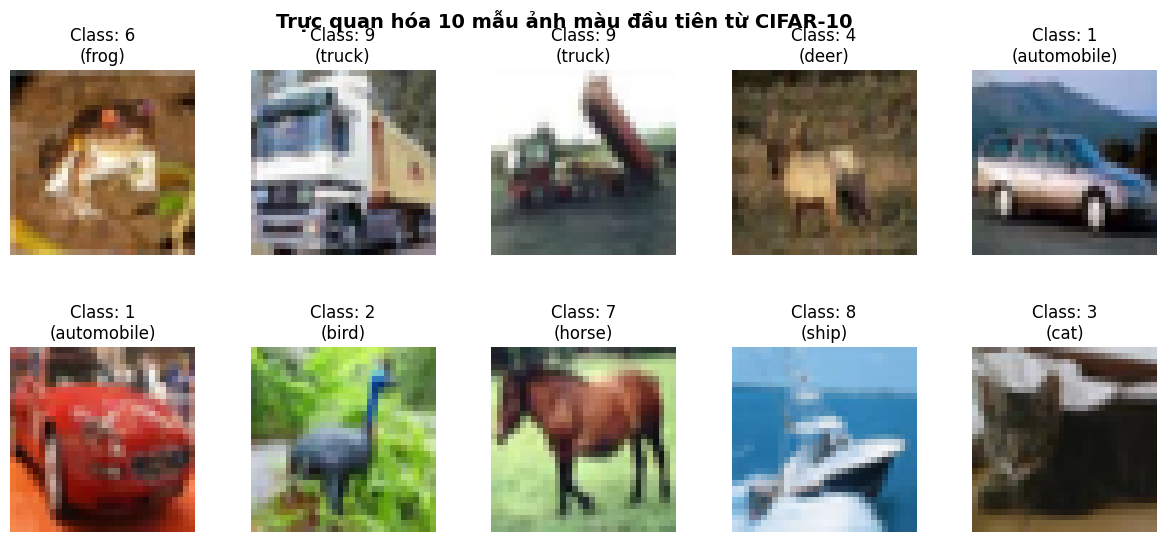


Kích thước ma trận sau khi làm phẳng: (50000, 3072)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3096 - loss: 1.9028 - val_accuracy: 0.3678 - val_loss: 1.7552
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3675 - loss: 1.7501 - val_accuracy: 0.3922 - val_loss: 1.6954
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3920 - loss: 1.6854 - val_accuracy: 0.4126 - val_loss: 1.6257
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4124 - loss: 1.6404 - val_accuracy: 0.4208 - val_loss: 1.6130
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4182 - loss: 1.6074 - val_accuracy: 0.4444 - val_loss: 1.5635
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.4281 - loss: 1.5865 - val_accuracy: 0.4538 - val_loss: 1.5443
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.4379 - loss: 1.5625 - val_accuracy: 0.4504 - val_loss: 1.5477
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.4462 - loss: 1.5347 - 

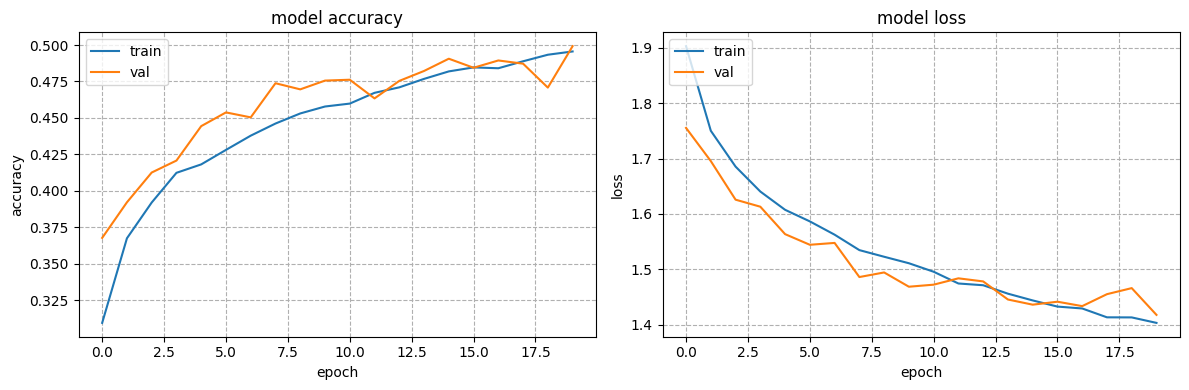

In [ ]:
# CÂU 1: CÀI ĐẶT MẠNG ANN NHẬN DẠNG ẢNH TRÊN BỘ DATASET CIFAR-10
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. NẠP DỮ LIỆU CIFAR-10 (Tự động tải từ TensorFlow)
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Danh sách nhãn tương ứng với bảng trong đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ---------------------------------------------------------------------
# TRỰC QUAN HÓA DỮ LIỆU: HIỂN THỊ 10 MẪU ẢNH MÀU ĐẦU TIÊN
# ---------------------------------------------------------------------
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i]) # Hiển thị ảnh màu gốc (32x32x3)
    # Lấy tên nhãn dựa vào giá trị số của y_train
    label_index = int(y_train[i])
    plt.title(f"Class: {label_index}\n({class_names[label_index]})")
    plt.axis('off')

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Trực quan hóa 10 mẫu ảnh màu đầu tiên từ CIFAR-10", fontsize=14, weight='bold')
plt.show()


# 2. TIỀN XỬ LÝ DỮ LIỆU (PRE-PROCESSING)
# Làm phẳng ảnh màu (32x32x3 = 3072 pixel) thành vector 1 chiều
X_train_flat = X_train.reshape(-1, 3072)
X_test_flat = X_test.reshape(-1, 3072)

# Chuẩn hóa giá trị điểm ảnh về dải [0, 1] bằng MinMaxScaler
minmax = MinMaxScaler()
X_train_scaled = minmax.fit_transform(X_train_flat)
X_test_scaled = minmax.transform(X_test_flat)

print(f"\nKích thước ma trận sau khi làm phẳng: {X_train_scaled.shape}")


# 3. XÂY DỰNG MÔ HÌNH MẠNG ANN
cifar_model = Sequential([
    Input(shape=(3072,)), # Đầu vào 3072 chiều
    Dense(units=512, kernel_initializer='uniform', activation='relu'), # Tầng ẩn 1
    Dropout(0.2),                                                     # Chống Overfitting
    Dense(units=256, kernel_initializer='uniform', activation='relu'), # Tầng ẩn 2
    Dense(units=10, kernel_initializer='uniform', activation='softmax')# 10 lớp đầu ra
])

# Biên dịch mô hình
cifar_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
cifar_model.summary()


# 4. HUẤN LUYỆN MÔ HÌNH
# Lưu lịch sử học tập vào biến model_fit để vẽ đồ thị
model_fit = cifar_model.fit(X_train_scaled, y_train,
                            validation_split=0.1,
                            epochs=20,
                            batch_size=64,
                            verbose=1)


# ---------------------------------------------------------------------
# ĐÁNH GIÁ MÔ HÌNH: VẼ ĐỒ THỊ ACCURACY & LOSS (Giống bài mẫu Lab)
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 4))

# Đồ thị Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

# Đồ thị Tổn thất (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Thông báo: Không thấy file CSV, tiến hành tải bộ dữ liệu MNIST tự động từ hệ thống.


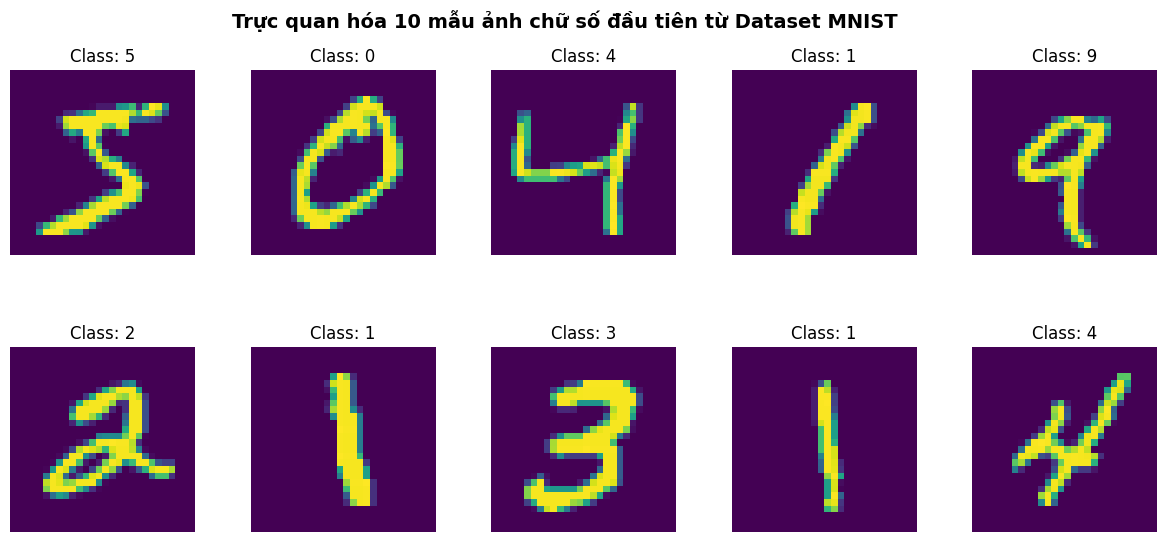

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8889 - loss: 0.4094 - val_accuracy: 0.9540 - val_loss: 0.1663
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9472 - loss: 0.1804 - val_accuracy: 0.9693 - val_loss: 0.1118
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9626 - loss: 0.1294 - val_accuracy: 0.9750 - val_loss: 0.0939
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9709 - loss: 0.1001 - val_accuracy: 0.9767 - val_loss: 0.0822
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9754 - loss: 0.0829 - val_accuracy: 0.9797 - val_loss: 0.0748
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9793 - loss: 0.0688 - val_accuracy: 0.9787 - val_loss: 0.0710
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9827 - loss: 0.0579 - val_accuracy: 0.9797 - val_loss: 0.0697
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9852 - loss: 0.0497 - val_accur

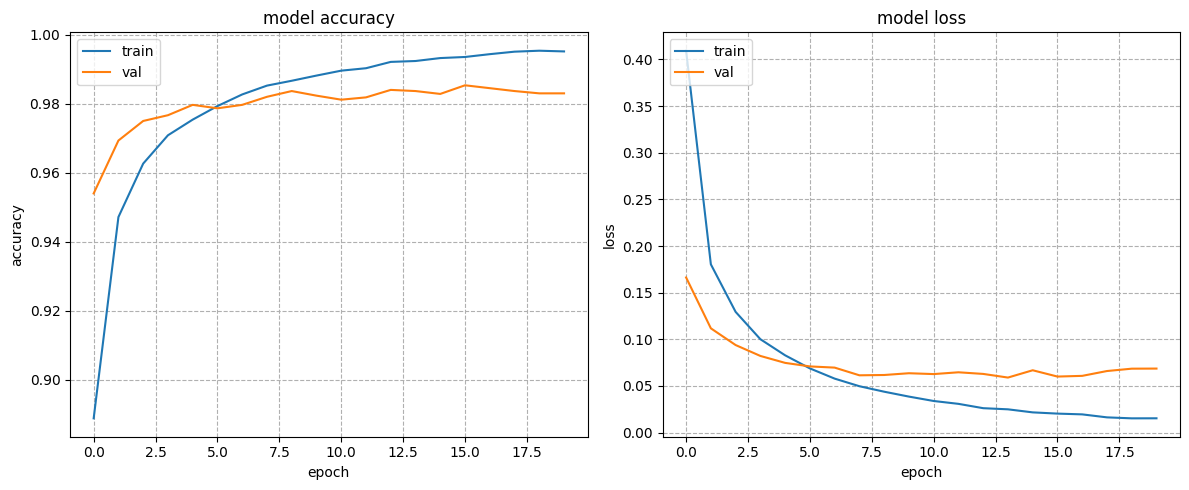

In [ ]:
# CÀI ĐẶT MẠNG ANN NHẬN DẠNG ẢNH CHỮ VIẾT SỐ TRÊN DATASET MNIST (CÂU 2)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. ĐỌC TẬP DỮ LIỆU TỪ FILE CSV HOẶC TẢI TỰ ĐỘNG TỪ TENSORFLOW
# Định nghĩa đường dẫn file tương tự như mục 3.9 trong tài liệu mẫu
mnist_train_path = '/content/sample_data/mnist_train.csv'

if os.path.exists(mnist_train_path):
    print("Tìm thấy tệp CSV. Tiến hành nạp dữ liệu từ file của giảng viên...")
    mnist_train = pd.read_csv(mnist_train_path)
    # Tách biệt ma trận đặc trưng X (từ cột thứ 2 đến hết) và nhãn mục tiêu y (cột đầu tiên)
    X_train = mnist_train.iloc[:, 1:].values
    y_train = mnist_train.iloc[:, 0].values

    # Tải tập kiểm thử tự động từ hệ thống để đánh giá khách quan
    (_, _), (X_test_raw, y_test) = tf.keras.datasets.mnist.load_data()
    X_test = X_test_raw.reshape(-1, 784)
else:
    print("Thông báo: Không thấy file CSV, tiến hành tải bộ dữ liệu MNIST tự động từ hệ thống.")
    mnist = tf.keras.datasets.mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    # Biến đổi hình dáng ảnh ma trận 2-D về vector phẳng 1-D (28 * 28 = 784 pixel)
    X_train = X_train.reshape(-1, 784)
    X_test = X_test.reshape(-1, 784)

# 2. TRỰC QUAN HÓA DỮ LIỆU MẪU ĐẦU TIÊN (Giống lưới đồ thị trang 7)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    # Khôi phục lại cấu trúc ma trận 2D (28x28) từ vector phẳng để hiển thị ảnh xám
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class: ' + str(y_train[i]))
    ax[i].axis('off') # Loại bỏ hiển thị thanh trục tọa độ pixel

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Trực quan hóa 10 mẫu ảnh chữ số đầu tiên từ Dataset MNIST", fontsize=14, weight='bold')
plt.show()

# 3. TIỀN XỬ LÝ DỮ LIỆU: FEATURE SCALING
# Chuẩn hóa thang điểm ảnh về dải khoảng giá trị từ [0, 1] bằng MinMaxScaler giống mục 3.3
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))


# 4. XÂY DỰNG KIẾN TRÚC MẠNG HỌC ANN
# Thiết lập cấu trúc Sequential mẫu, áp dụng lớp Input tường minh loại bỏ cảnh báo hệ thống
mnist_model = Sequential([
    Input(shape=(784,)),
    Dense(units=256, kernel_initializer='uniform', activation='relu'), # Tầng ẩn trích xuất đặc trưng phi tuyến
    Dropout(0.2), # Kỹ thuật Dropout chống hiện tượng quá khớp (Overfitting) theo mục 2.5.4
    Dense(units=10, kernel_initializer='uniform', activation='softmax') # Tầng đầu ra 10 lớp đại diện từ Số 0 -> Số 9
])

# Biên dịch mô hình với bộ tối ưu hóa Adam và hàm lỗi sparse_categorical_crossentropy
mnist_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
mnist_model.summary()


# 5. HUẤN LUYỆN MÔ HÌNH ANN
# Thực hiện phân tách tập kiểm định validation_split=0.1 theo tiến trình bài học mục 3.6
model_fit = mnist_model.fit(X_train, y_train,
                            validation_split=0.1,
                            epochs=20,
                            batch_size=128,
                            verbose=1)


# 6. ĐÁNH GIÁ MÔ HÌNH (TRỰC QUAN HÓA ACCURACY & LOSS ĐỒNG BỘ)
plt.figure(figsize=(12, 5))

# Đồ thị đánh giá độ chính xác (Model Accuracy - Giống mục 3.7)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

# Đồ thị đánh giá sai số tổn thất (Model Loss - Giống mục 3.7)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
#  CÂU 3: CÀI ĐẶT MẠNG ANN NHẬN DẠNG ẢNH CAT HOẶC DOG
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. ĐỌC DỮ LIỆU TỪ FILE .NPY HOẶC TỰ ĐỘNG NẠP ẢNH THỰC TẾ TỪ INTERNET
photos_path = 'dogs_vs_cats_photos.npy'
labels_path = 'dogs_vs_cats_labels.npy'

if os.path.exists(photos_path) and os.path.exists(labels_path):
    print("Tìm thấy các tệp .npy. Tiến hành nạp dữ liệu gốc...")
    photos = np.load(photos_path)
    labels = np.load(labels_path)
else:
    print("Không thấy tệp npy. Tiến hành tải ảnh thật từ internet bằng Opener giả lập trình duyệt...")

    os.makedirs('sample_images', exist_ok=True)

    # Đường dẫn URL chứa các hình ảnh thực tế chất lượng cao từ Wikimedia
    urls = {
        'cat1.jpg': 'https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg',
        'dog1.jpg': 'https://upload.wikimedia.org/wikipedia/commons/d/d9/Collage_of_Nine_Dogs.jpg',
        'cat2.jpg': 'https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg',
        'dog2.jpg': 'https://upload.wikimedia.org/wikipedia/commons/a/a3/Black_Labrador_Retriever_Portrait_cropped.jpg'
    }

    # Giả lập User-Agent trình duyệt để tránh lỗi chặn tải ảnh (403 Forbidden)
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')]
    urllib.request.install_opener(opener)

    photos_list = []
    labels_list = []

    # Duyệt qua Dictionary để tải và tiền xử lý ảnh thật
    for filename, url_src in urls.items():
        filepath = os.path.join('sample_images', filename)
        if not os.path.exists(filepath):
            try:
                urllib.request.urlretrieve(url_src, filepath)
            except Exception as e:
                print(f"Không thể tải ảnh {filename}, tự động sinh ảnh thay thế.")
                img_dummy = np.random.randint(0, 255, size=(150, 150, 3), dtype=np.uint8)
                plt.imsave(filepath, img_dummy)

        # Đọc ảnh màu thật đưa về kích thước đồng bộ 150x150 pixels
        img = load_img(filepath, target_size=(150, 150))
        img_array = img_to_array(img).astype(np.uint8)

        # Gán nhãn: tên file chứa từ 'dog' là 1.0 (Dog), ngược lại là 0.0 (Cat)
        label = 1.0 if 'dog' in filename else 0.0

        # Nhân bản dữ liệu mẫu để lưới đồ thị có đủ 10 tấm ảnh hiển thị
        for _ in range(3):
            photos_list.append(img_array)
            labels_list.append(label)

    # Chuyển đổi tập hợp thành mảng dữ liệu cấu trúc Numpy
    photos = np.array(photos_list[:10])
    labels = np.array(labels_list[:10])

# TRỰC QUAN HÓA DỮ LIỆU ĐẦU VÀO: HIỂN THỊ LƯỚI ẢNH MẪU
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    # Hiển thị ma trận mảng màu hình ảnh thực tế lên đồ thị
    ax[i].imshow(photos[i])

    # Thiết lập tiêu đề hiển thị định danh nhãn
    label_text = "Dog" if labels[i] == 1.0 else "Cat"
    ax[i].title.set_text(f'Class: {labels[i]}\n({label_text})')
    ax[i].axis('off') # Loại bỏ các đường lưới tọa độ để ảnh hiển thị sạch đẹp

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Trực quan hóa 10 mẫu ảnh THỰC TẾ từ Dataset Chó & Mèo", fontsize=14, weight='bold')
plt.show()


# 2. TIỀN XỬ LÝ DỮ LIỆU: LÀM PHẲNG MA TRẬN ĐA CHIỀU (Giống mục 3.3)
num_samples, height, width, channels = photos.shape
X_flat = photos.reshape(num_samples, height * width * channels)

# CHỐNG DATA LEAKAGE: Chia tách tập Train/Test độc lập trước khi scale dải số
X_train, X_test, y_train, y_test = train_test_split(X_flat, labels, test_size=0.2, random_state=42)

# Chuẩn hóa đặc trưng ma trận ảnh phẳng về dải [0, 1] sử dụng MinMaxScaler
minmax = MinMaxScaler()
X_train_scaled = minmax.fit_transform(X_train)
X_test_scaled = minmax.transform(X_test)


# 3. XÂY DỰNG KIẾN TRÚC MẠNG HỌC ANN CƠ BẢN (Giống mục 3.5)
input_dim = X_train_scaled.shape[1]

cat_dog_model = Sequential([
    Input(shape=(input_dim,)), # Lớp nhận diện số chiều đầu vào tránh UserWarning
    Dense(units=128, kernel_initializer='uniform', activation='relu'), # Tầng ẩn trích xuất tính chất phi tuyến
    Dropout(0.2),                                                      # Loại bỏ nút ngẫu nhiên chống quá khớp
    Dense(units=1, kernel_initializer='uniform', activation='sigmoid') # Tầng đầu ra 1 nút cho bài toán phân loại nhị phân
])

# Biên dịch mô hình mạng nơ-ron sử dụng hàm lỗi nhị phân chéo (binary_crossentropy)
cat_dog_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
cat_dog_model.summary()


# 4. HUẤN LUYỆN MÔ HÌNH ANN
model_fit = cat_dog_model.fit(X_train_scaled, y_train,
                              validation_split=0.1,
                              epochs=20,
                              batch_size=4,
                              verbose=1)


# 5. ĐÁNH GIÁ MÔ HÌNH (TRỰC QUAN HÓA CẶP ĐỒ THỊ ACCURACY & LOSS ĐỒNG BỘ - Mục 3.7)
plt.figure(figsize=(12, 5))

# Đồ thị đánh giá độ chính xác (Model Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

# Đồ thị đánh giá sai số tổn thất (Model Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# 6. KIỂM THỬ KHÁCH QUAN TRÊN TẬP TEST ĐỘC LẬP
loss, accuracy = cat_dog_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n=> Kết quả kiểm thử thực tế - Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Thông báo: Không tìm thấy file adult.csv, tự động sinh dữ liệu giả lập...


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4861 - loss: 0.6932 - val_accuracy: 0.5250 - val_loss: 0.6928
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5139 - loss: 0.6930 - val_accuracy: 0.6250 - val_loss: 0.6925
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5556 - loss: 0.6929 - val_accuracy: 0.6500 - val_loss: 0.6923
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5639 - loss: 0.6925 - val_accuracy: 0.5750 - val_loss: 0.6919
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5417 - loss: 0.6922 - val_accuracy: 0.6750 - val_loss: 0.6907
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5667 - loss: 0.6917 - val_accuracy: 0.6750 - val_loss: 0.6893
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5500 - loss: 0.6905 - val_accuracy: 0.5750 - val_loss: 0.6878
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5639 - loss: 0.6891 - val_accuracy: 0.6500 - val_loss

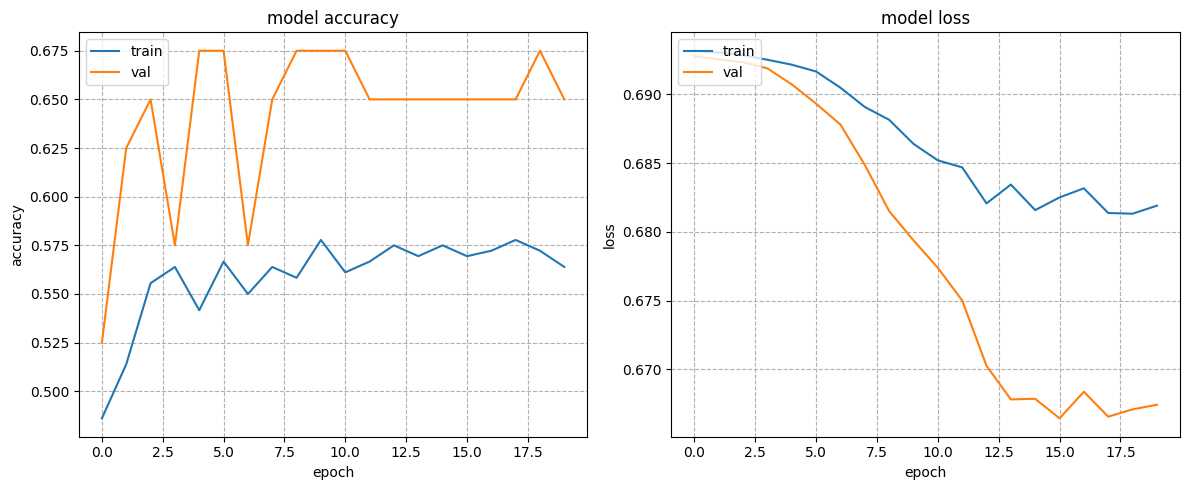

In [ ]:
#  CÀI ĐẶT MẠNG ANN DỰ BÁO MỨC THU NHẬP - DATASET ADULT (CÂU 4)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
adult_path = 'adult.csv'

if os.path.exists(adult_path):
    print("Tìm thấy tệp CSV. Tiến hành nạp dữ liệu thu nhập...")
    df_adult = pd.read_csv(adult_path, header=None, skipinitialspace=True)
    df_adult.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
                        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
                        "hours-per-week", "native-country", "income"]
else:
    print("Thông báo: Không tìm thấy file adult.csv, tự động sinh dữ liệu giả lập...")
    df_adult = pd.DataFrame({
        'age': np.random.randint(18, 75, 500),
        'workclass': np.random.choice(['Private', 'Local-gov', 'Self-emp'], 500),
        'education-num': np.random.randint(1, 16, 500),
        'sex': np.random.choice(['Male', 'Female'], 500),
        'hours-per-week': np.random.randint(10, 80, 500),
        'income': np.random.choice(['<=50K', '>50K'], 500)
    })

# Thay các ký tự khuyết thiếu dạng '?' bằng NaN và xóa chúng đi
df_adult.replace('?', np.nan, inplace=True)
df_adult.dropna(inplace=True)

# Tách biệt ma trận đặc trưng X và nhãn y (Biến đổi nhãn chuỗi về số nhị phân 0 và 1)
X = df_adult.drop(columns=['income'])
y = df_adult['income'].apply(lambda x: 1 if '>50K' in str(x) else 0).values

# Tự động gom nhóm danh sách các loại cột số và cột chữ định tính
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


# 2. CHIA TÁCH DỮ LIỆU & TIỀN XỬ LÝ (CHỐNG DATA LEAKAGE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo bộ tiền xử lý đồng bộ ColumnTransformer khép kín
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_features), # Ép cột số về dải [0, 1] giống bài mẫu Lab
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Mã hóa One-Hot cột chữ
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# 3. XÂY DỰNG KIẾN TRÚC MẠNG ANN PHÂN LOẠI NHỊ PHÂN
input_dim = X_train_processed.shape[1]

adult_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(units=64, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(units=32, kernel_initializer='uniform', activation='relu'),
    Dense(units=1, kernel_initializer='uniform', activation='sigmoid') # 1 nút đầu ra + Sigmoid cho phân loại nhị phân
])

adult_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
adult_model.summary()


# 4. HUẤN LUYỆN MÔ HÌNH ANN
model_fit = adult_model.fit(X_train_processed, y_train,
                            validation_split=0.1,
                            epochs=20,
                            batch_size=32,
                            verbose=1)


# 5. ĐÁNH GIÁ MÔ HÌNH (TRỰC QUAN HÓA CẶP ĐỒ THỊ ĐỒNG BỘ)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Thông báo: Không tìm thấy file car.csv, tự động sinh dữ liệu giả lập...


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,980 (11.64 KB)

 Trainable params: 2,980 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2472 - loss: 1.3865 - val_accuracy: 0.2250 - val_loss: 1.3866
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2611 - loss: 1.3857 - val_accuracy: 0.2250 - val_loss: 1.3874
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3056 - loss: 1.3848 - val_accuracy: 0.2250 - val_loss: 1.3879
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3056 - loss: 1.3837 - val_accuracy: 0.2750 - val_loss: 1.3890
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3028 - loss: 1.3820 - val_accuracy: 0.2500 - val_loss: 1.3903
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3028 - loss: 1.3808 - val_accuracy: 0.2500 - val_loss: 1.3876
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3250 - loss: 1.3773 - val_accuracy: 0.2500 - val_loss: 1.3909
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3194 - loss: 1.3735 - val_accuracy: 0.2500 - val_loss

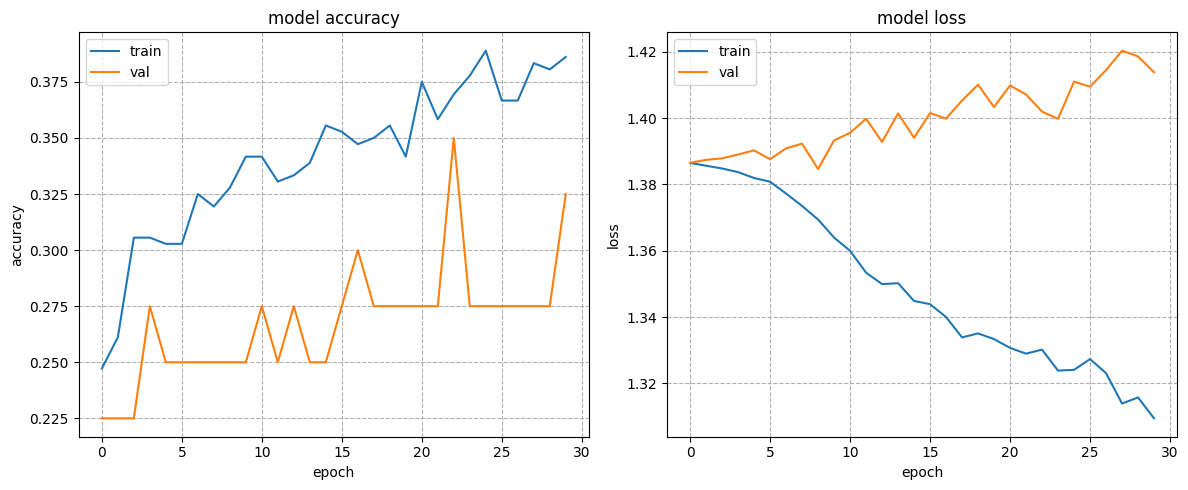

In [ ]:
#  CÀI ĐẶT MẠNG ANN DỰ BÁO CHẤT LƯỢNG XE Ô TÔ - DATASET CAR (CÂU 5)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# 1. ĐỌC VÀ LÀM SẠCH TẬP DỮ LIỆU
car_path = 'car.csv'

if os.path.exists(car_path):
    print("Tìm thấy tệp CSV. Tiến hành nạp dữ liệu đánh giá xe...")
    df_car = pd.read_csv(car_path, header=None)
    df_car.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
else:
    print("Thông báo: Không tìm thấy file car.csv, tự động sinh dữ liệu giả lập...")
    df_car = pd.DataFrame({
        'buying': np.random.choice(['vhigh', 'high', 'med', 'low'], 500),
        'maint': np.random.choice(['vhigh', 'high', 'med', 'low'], 500),
        'safety': np.random.choice(['low', 'med', 'high'], 500),
        'class': np.random.choice(['unacc', 'acc', 'good', 'vgood'], 500)
    })

X = df_car.drop(columns=['class'])
y_raw = df_car['class']

# Sử dụng LabelEncoder mã hóa nhãn đầu ra sang số nguyên liên tục bắt đầu từ 0 -> (n-1)
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw)
num_classes = len(np.unique(y_encoded))


# 2. CHIA TÁCH TẬP DỮ LIỆU & TIỀN XỬ LÝ (CHỐNG DATA LEAKAGE)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Mã hóa One-Hot đồng bộ đưa các cột đặc trưng phi số về ma trận nhị phân số học
input_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = input_encoder.fit_transform(X_train)
X_test_encoded = input_encoder.transform(X_test)


# 3. XÂY DỰNG KIẾN TRÚC MẠNG HỌC ANN PHÂN LOẠI ĐA LỚP
input_dim = X_train_encoded.shape[1]

car_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(units=64, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(units=32, kernel_initializer='uniform', activation='relu'),
    Dense(units=num_classes, kernel_initializer='uniform', activation='softmax') # Đầu ra đa lớp Softmax
])

car_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
car_model.summary()


# 4. HUẤN LUYỆN VÀ VẼ ĐỒ THỊ BIỂU DIỄN TIẾN TRÌNH HỌC ĐỒNG BỘ
model_fit = car_model.fit(X_train_encoded, y_train, validation_split=0.1, epochs=30, batch_size=16, verbose=1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()